# 01 · Exploratory analysis: how fast is the shift to BEVs?

**Business question:** How fast is Sweden shifting to battery-electric cars among private buyers, where is it fastest or slowest and why, and what BEV share is plausible by 2028?

This notebook covers the first part, **how fast**. It describes the national trend, compares private buyers with company and dealer registrations, measures the speed of change and checks for seasonality. Regional differences (02), the climate-bonus effect (03) and the forecast (04) build on what is found here.

**Metrics (see `CLAUDE.md`)**
- **BEV share** = BEV new registrations ÷ all new passenger-car registrations (all eight fuel types). Every share over more than one month is a *ratio of sums*, never an average of monthly shares.
- **Private buyers** (`owner_type = private`) are the headline population. They're only available from Jan 2021. The all-owner series (2006 onwards) is long-run context and is always labelled *all owners*.
- **PHEV share** is reported alongside BEV but never added to it.
- The climate bonus ended on **8 Nov 2022**.
- Data runs through **Aug 2026**, so 2026 is always a partial year (Jan–Aug).

## 1. Setup and data checks

**Choices made here**
- Read the processed CSVs rather than SQLite. They hold the same tables, and pandas reads CSV directly. The SQLite copy is for the `sql/` phase and Power BI.
- The county fact table leaves out zero cells (see `SOURCES.md`), so the pivot fills missing owner × fuel × month combinations with **0**. If they were dropped instead, any month with zero registrations for a fuel type would vanish.
- Chart style is defined once: thin lines, light gridlines, BEV in blue and PHEV in orange. When private buyers are compared with other owner types, private is the only coloured line and the others are grey, so the headline population stands out.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC, FIGS = ROOT / "data" / "processed", ROOT / "docs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

FUELS = ["BEV", "PHEV", "HEV", "PETROL", "DIESEL", "ETHANOL", "GAS", "OTHER"]
BONUS_END = pd.Timestamp("2022-11-08")

# Chart style: validated default palette slots 1-2, recessive chrome
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
INK, INK2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
GREY_DARK, GREY_LIGHT, SURFACE = "#6f6e69", "#b5b3ab", "#fcfcfb"
mpl.rcParams.update({
    "figure.figsize": (10, 4.2), "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelcolor": INK2, "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "ytick.left": False, "lines.linewidth": 2, "legend.frameon": False,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
})
PCT = mpl.ticker.PercentFormatter(1.0, decimals=0)

def mark_bonus(ax, y=0.97):
    ax.axvline(BONUS_END, color=AXIS, lw=1, zorder=0)
    ax.annotate("Bonus ends 8 Nov 2022", (BONUS_END, y), xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points", fontsize=8.5, color=INK2, va="top")

def label_end(ax, s, text, dy=0):
    s = s.dropna()
    ax.annotate(text, (s.index[-1], s.iloc[-1]), xytext=(6, dy), textcoords="offset points",
                fontsize=9, color=INK2, va="center")

def save(fig, name):
    fig.savefig(FIGS / f"{name}.png")

In [2]:
nat = pd.read_csv(PROC / "national_monthly_by_fuel.csv", parse_dates=["month"]).set_index("month")
fact = pd.read_csv(PROC / "fact_registrations_county_monthly.csv", parse_dates=["month"],
                   dtype={"county_code": str})

months = pd.date_range(fact.month.min(), fact.month.max(), freq="MS")
own = (fact.pivot_table(index=["owner_type", "month"], columns="fuel_type", values="registrations",
                        aggfunc="sum", fill_value=0)
           .reindex(columns=FUELS, fill_value=0))
own["total"] = own[FUELS].sum(axis=1)
by_owner = {o: own.loc[o].reindex(months, fill_value=0) for o in ["private", "company", "dealer"]}
priv = by_owner["private"]
LAST = months[-1]

print(f"National series: {nat.index.min():%Y-%m} → {nat.index.max():%Y-%m}  ({len(nat)} months, "
      f"gaps: {len(pd.date_range(nat.index.min(), nat.index.max(), freq='MS')) - len(nat)})")
print(f"County fact:     {months[0]:%Y-%m} → {LAST:%Y-%m}  ({fact.month.nunique()} of {len(months)} months present)")

National series: 2006-01 → 2026-08  (248 months, gaps: 0)
County fact:     2021-01 → 2026-08  (68 of 68 months present)


In [3]:
# Check 1: the county fact table sums to the national t10036 series in every overlapping month
val = pd.read_csv(PROC / "_validation_national_vs_county.csv")
print("Max |national - county sum| difference:", val.abs_pct_diff.max())

# Check 2: the private BEV share rebuilt here matches the column produced by build_dataset.py
rebuilt = (priv.BEV / priv.total).round(5)
print("Private BEV share matches build output:", np.allclose(rebuilt, nat.loc[months, "private_bev_share"]))

# Owner mix: what fraction of all new registrations each buyer type accounts for
mix = pd.DataFrame({o: d.total for o, d in by_owner.items()})
mix_year = mix.groupby(mix.index.year).sum()
(mix_year.div(mix_year.sum(axis=1), axis=0)
         .rename(index={LAST.year: f"{LAST.year} (Jan–{LAST:%b})"})
         .style.format("{:.1%}").set_caption("Share of all new registrations by owner type"))

Max |national - county sum| difference: 0.0
Private BEV share matches build output: True


,private,company,dealer
2021,39.6%,41.1%,19.3%
2022,41.9%,42.3%,15.8%
2023,30.9%,48.5%,20.6%
2024,32.4%,45.4%,22.1%
2025,35.2%,43.1%,21.7%
2026 (Jan–Aug),37.6%,44.0%,18.4%


**What the checks show.** The county fact table matches the national series exactly in every month, and the private BEV share rebuilt here matches the build output. Both data paths are consistent.

The owner mix moves a lot, and that matters for everything below. Private buyers were about **40%** of the market in 2021–22, fell to **31%** in 2023, the first year without the bonus, and have recovered to about **38%** in 2026. Companies (mostly leasing) are the largest group. Because the mix shifts, the all-owner BEV share can move even when no buyer type changes its behaviour. That's one more reason to keep private buyers separate.

## 2. Long-run context: all owners, 2006–2026

**Choice:** this section uses the **all-owner** national series. It's the only one that goes back before 2021, and it shows where the private-buyer period sits on the longer adoption curve. Shares are **annual ratios of sums**. 2026 is plotted separately as Jan–Aug, because a partial year can't be compared directly with full years (see the seasonality in section 5).

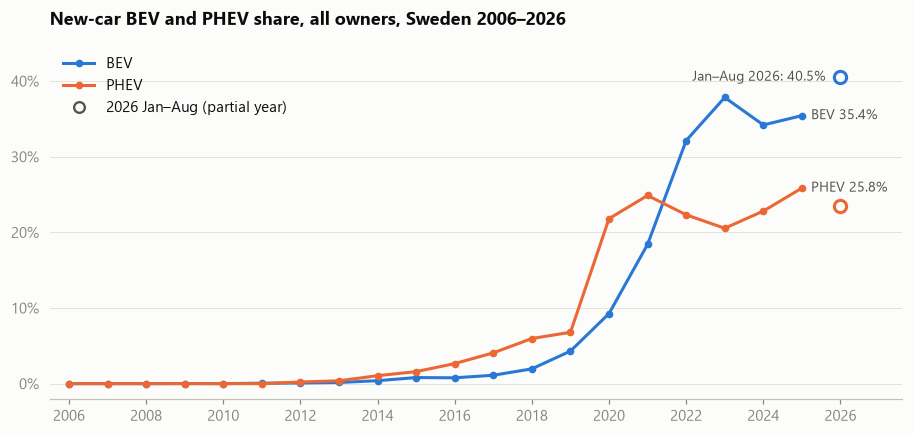

,total,BEV,PHEV,bev_share,phev_share
month,,,,,
2015,"361,932","2,916","5,752",0.8%,1.6%
2016,"388,014","2,993","10,290",0.8%,2.7%
2017,"392,728","4,359","15,989",1.1%,4.1%
2018,"365,535","7,147","21,811",2.0%,6.0%
2019,"366,961","15,795","24,907",4.3%,6.8%
2020,"303,196","28,097","66,134",9.3%,21.8%
2021,"314,313","57,881","78,200",18.4%,24.9%
2022,"299,220","96,163","66,775",32.1%,22.3%
2023,"298,107","112,775","61,235",37.8%,20.5%


In [4]:
ann = nat.groupby(nat.index.year)[["total", "BEV", "PHEV"]].sum()
ann["bev_share"] = ann.BEV / ann.total
ann["phev_share"] = ann.PHEV / ann.total
full, ytd = ann.loc[: LAST.year - 1], ann.loc[[LAST.year]]

fig, ax = plt.subplots()
for col, color, name in [("bev_share", BLUE, "BEV"), ("phev_share", ORANGE, "PHEV")]:
    ax.plot(full.index, full[col], color=color, label=name, marker="o", ms=4)
    ax.plot(ytd.index, ytd[col], color=color, marker="o", ms=8, mfc=SURFACE, mew=2, ls="none")
    label_end(ax, full[col], f"{name} {full[col].iloc[-1]:.1%}")
ax.annotate(f"Jan–Aug {LAST.year}: {ytd.bev_share.iloc[0]:.1%}", (LAST.year, ytd.bev_share.iloc[0]),
            xytext=(-10, 0), textcoords="offset points", ha="right", va="center", fontsize=9, color=INK2)
ax.yaxis.set_major_formatter(PCT)
ax.set_xticks(range(2006, LAST.year + 1, 2))
ax.set_xlim(2005.5, LAST.year + 1.6)
ax.set_ylim(top=0.45)
ax.set_title("New-car BEV and PHEV share, all owners, Sweden 2006–2026")
handles, _ = ax.get_legend_handles_labels()
partial = mpl.lines.Line2D([], [], color=INK2, marker="o", ms=7, mfc=SURFACE, mew=1.5, ls="none")
ax.legend(handles + [partial], ["BEV", "PHEV", f"{LAST.year} Jan–Aug (partial year)"], loc="upper left")
save(fig, "01_longrun_all_owners")
plt.show()

ann.loc[2015:].style.format({"total": "{:,.0f}", "BEV": "{:,.0f}", "PHEV": "{:,.0f}",
                             "bev_share": "{:.1%}", "phev_share": "{:.1%}"})

**Reading the long-run picture**
- BEVs were negligible (under **1%**) until 2016, then roughly doubled every year: **4.3%** in 2019, **9.3%** in 2020, **18.4%** in 2021 and **32.1%** in 2022.
- Growth then **stalled**: **37.8%** in 2023, a *fall* to **34.2%** in 2024 and **35.4%** in 2025. The Jan–Aug 2026 figure of **40.5%** is the first clear step up in three years.
- PHEVs have *not* been displaced. Their share jumped to about 22% in 2020 and has stayed between **20% and 26%** since. Together, plug-ins are about 60% of the 2025 market.
- For reference, Mobility Sweden publishes slightly different figures (2023: 38.7% vs 37.8% here) because of timing and definitions. This project uses Trafikanalys throughout.

So the all-owner curve looks like fast S-curve growth, then a plateau from 2023, then a restart. The next question is whether private buyers follow the same path.

## 3. Private buyers compared with company and dealer registrations, 2021–2026

**Choice: the rolling 12-month (R12) share is the main lens.** Monthly shares swing by ±10 pp because of the quarter-end spikes (section 5) and the bonus rush. R12 = BEV registrations in the last 12 months ÷ all registrations in the last 12 months. It removes seasonality and is still a ratio of sums. The trade-off is lag: R12 shows a change about six months late on average, and a single extreme month (Dec 2022) stays in it for a full year. Monthly values are drawn faintly behind it so both are visible. The first R12 value is Dec 2021.

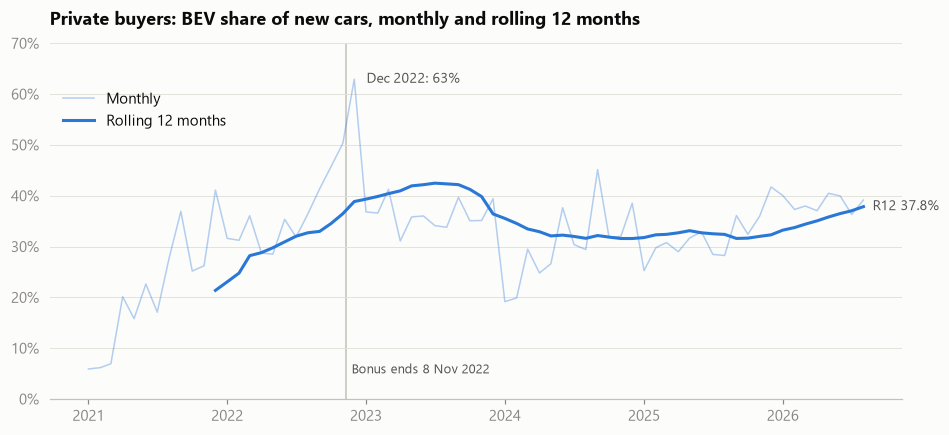

In [5]:
def r12(d, fuel="BEV"):
    return d[fuel].rolling(12).sum() / d["total"].rolling(12).sum()

p_month, p_r12 = priv.BEV / priv.total, r12(priv)

fig, ax = plt.subplots()
ax.plot(p_month.index, p_month, color=BLUE, lw=1, alpha=0.35, label="Monthly")
ax.plot(p_r12.index, p_r12, color=BLUE, label="Rolling 12 months")
pk = p_month.idxmax()
ax.annotate(f"{pk:%b %Y}: {p_month[pk]:.0%}", (pk, p_month[pk]), xytext=(8, 0), textcoords="offset points",
            fontsize=9, color=INK2, va="center")
label_end(ax, p_r12, f"R12 {p_r12.iloc[-1]:.1%}")
mark_bonus(ax, y=0.1)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 0.7)
ax.set_title("Private buyers: BEV share of new cars, monthly and rolling 12 months")
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.9))
save(fig, "01_private_bev_share")
plt.show()

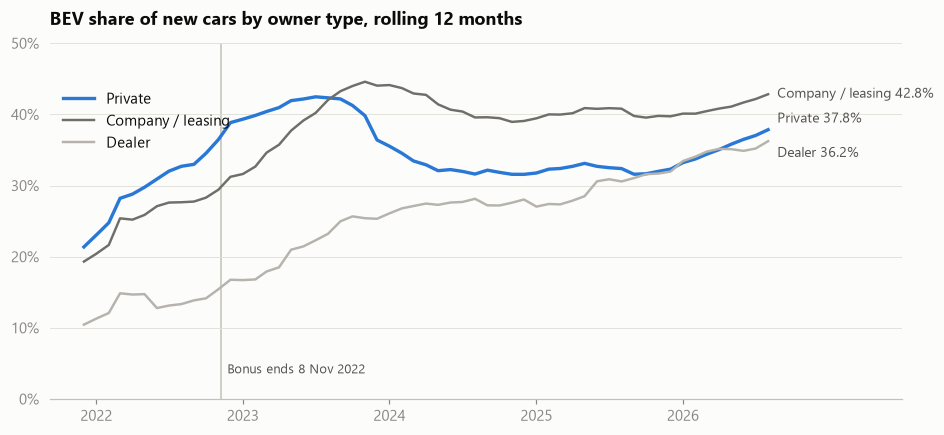

In [6]:
fig, ax = plt.subplots()
styles = {"private": (BLUE, 2.2, "Private"), "company": (GREY_DARK, 1.6, "Company / leasing"),
          "dealer": (GREY_LIGHT, 1.6, "Dealer")}
for o, (color, lw, name) in styles.items():
    s = r12(by_owner[o])
    ax.plot(s.index, s, color=color, lw=lw, label=name)
    label_end(ax, s, f"{name} {s.iloc[-1]:.1%}", dy={"private": 7, "company": 0, "dealer": -8}[o])
mark_bonus(ax, y=0.1)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 0.5)
ax.set_xlim(right=LAST + pd.DateOffset(months=11))
ax.set_xticks(pd.date_range(f"{months[0].year + 1}-01-01", f"{LAST.year}-01-01", freq="YS"))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%Y"))
ax.set_title("BEV share of new cars by owner type, rolling 12 months")
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.9))
save(fig, "01_bev_share_by_owner")
plt.show()

In [7]:
rows = {}
for o, d in by_owner.items():
    y = d.groupby(d.index.year)[["BEV", "PHEV", "total"]].sum()
    rows[(o, "BEV")] = y.BEV / y.total
    rows[(o, "PHEV")] = y.PHEV / y.total
tbl = pd.DataFrame(rows).T
tbl.columns = [f"{c} (Jan–{LAST:%b})" if c == LAST.year else str(c) for c in tbl.columns]
tbl.style.format("{:.1%}").set_caption("Annual share of new registrations by owner type (ratio of sums)")

**What this shows**
- **Private BEV share rose fast with the bonus and then went backwards.** R12 went from **21%** (Dec 2021) to **42%** (mid-2023). That peak is partly mechanical: the Nov–Dec 2022 rush before the bonus ended (Dec 2022 was **63%** BEV) stays in the 12-month window until late 2023. Once the rush dropped out, the private share fell to about **32%** and stayed at 31–33% from mid-2024 through 2025. It has risen since late 2025, to **37.8%** R12 by Aug 2026.
- **Companies overtook private buyers in 2023 and have stayed ahead.** The company BEV share kept rising after the bonus ended (31% → 44% in 2023), probably because company-car taxation, not the consumer bonus, drives those decisions. That's a hypothesis notebook 03 can test.
- **Dealer registrations rose steadily** from 10% to 38% BEV. These are demo cars and pre-registrations, which often reach private owners later as nearly new used cars. They're excluded from the headline but are worth noting: they're a second route by which BEVs reach households.
- **The private PHEV share** stayed around 14–20%, well below the company PHEV share (25–35%).

## 4. How fast is it changing?

**Choices: two ways to measure speed.**
1. **Same-period comparison:** the Jan–Aug share each year. This is the only fair way to put 2026 next to earlier years without mixing in different months.
2. **Year-on-year change in R12** (percentage points): R12 this month minus R12 twelve months earlier. It gives a smooth monthly reading of acceleration or deceleration from Dec 2022.

A share can rise because BEV sales grow or because non-BEV sales shrink. The table therefore also shows the growth in BEV *volume* and in the total private market, so it's clear which one drives a change in share.

In [8]:
m = LAST.month
p8 = priv[priv.index.month <= m]
ytd = p8.groupby(p8.index.year)[["BEV", "total"]].sum()
ytd["bev_share"] = ytd.BEV / ytd.total
ytd["share_change_pp"] = ytd.bev_share.diff() * 100
ytd["bev_volume_yoy"] = ytd.BEV.pct_change()
ytd["private_market_yoy"] = ytd.total.pct_change()
ytd.style.format({"BEV": "{:,.0f}", "total": "{:,.0f}", "bev_share": "{:.1%}", "share_change_pp": "{:+.1f}",
                  "bev_volume_yoy": "{:+.1%}", "private_market_yoy": "{:+.1%}"}, na_rep="–") \
         .set_caption(f"Private buyers, Jan–{LAST:%b} each year")

fuel_type,BEV,total,bev_share,share_change_pp,bev_volume_yoy,private_market_yoy
2021,"12,531","81,913",15.3%,–,–,–
2022,"27,066","83,248",32.5%,+17.2,+116.0%,+1.6%
2023,"20,921","58,416",35.8%,+3.3,-22.7%,-29.8%
2024,"15,005","53,676",28.0%,-7.9,-28.3%,-8.1%
2025,"18,319","61,654",29.7%,+1.8,+22.1%,+14.9%
2026,"27,597","71,577",38.6%,+8.8,+50.6%,+16.1%


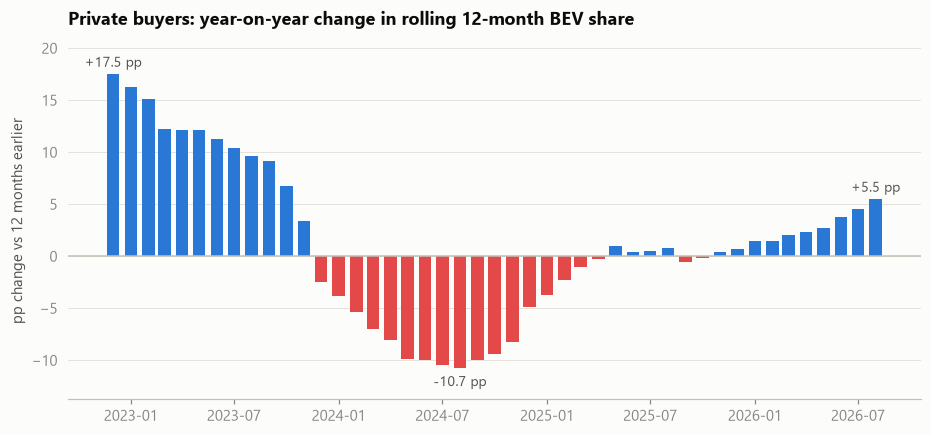

In [9]:
yoy = ((p_r12 - p_r12.shift(12)) * 100).dropna()

fig, ax = plt.subplots()
ax.bar(yoy.index, yoy, width=22, color=np.where(yoy >= 0, BLUE, RED))
ax.axhline(0, color=AXIS, lw=1)
ax.set_ylim(yoy.min() - 3, yoy.max() + 3)
for d in [yoy.idxmax(), yoy.idxmin(), yoy.index[-1]]:
    ax.annotate(f"{yoy[d]:+.1f} pp", (d, yoy[d]), xytext=(0, 5 if yoy[d] >= 0 else -12),
                textcoords="offset points", ha="center", fontsize=9, color=INK2)
ax.set_ylabel("pp change vs 12 months earlier")
ax.set_title("Private buyers: year-on-year change in rolling 12-month BEV share")
save(fig, "01_private_r12_yoy")
plt.show()

**Speed, in numbers** (Jan–Aug comparisons from the table, R12 changes from the chart)
- **2022: +17.2 pp.** The bonus period was the fastest growth in the series. BEV volume more than doubled (+116%) while the private market stayed flat (+1.6%).
- **2023: +3.3 pp, but it's a denominator effect.** BEV volume actually *fell* 23%. The share still rose because the whole private market fell faster (−30%), so private buyers bought fewer cars of every kind.
- **2024: −7.9 pp.** The real setback: BEV volume fell another 28% while the market fell only 8%. The year-on-year R12 change bottomed at **−10.7 pp** (Aug 2024).
- **2025: +1.8 pp.** BEV volume recovered (+22%), only slightly faster than the market (+15%). The R12 change stayed near zero and only turned positive in Nov 2025.
- **2026: +8.8 pp** (**29.7% → 38.6%**), the largest gain since the bonus era. BEV volume is up **51%** against a market up 16%, so this is **genuine BEV growth, not a shrinking denominator**. The R12 change is **+5.5 pp** in Aug 2026.

Over the whole period the private BEV share went from about **15% to 39%** (Jan–Aug 2021 → 2026), roughly **+5 pp a year on average**. That average hides a stop-start pattern: a bonus-driven surge, a two-year decline and plateau, and a restart in 2026.